In [2]:
import pandas as pd

In [4]:
orders = pd.read_csv(
    "../data/cleaned/olist_orders_clean.csv",
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

customers = pd.read_csv(
    "../data/cleaned/olist_customers_clean.csv"
)

order_items = pd.read_csv(
    "../data/cleaned/olist_order_items_clean.csv",
    parse_dates=['shipping_limit_date']
)

payments = pd.read_csv(
    "../data/cleaned/olist_order_payments_clean.csv"
)

reviews = pd.read_csv(
    "../data/cleaned/olist_order_reviews_clean.csv",
    parse_dates=[
        'review_creation_date',
        'review_answer_timestamp'
    ]
)

products = pd.read_csv(
    "../data/cleaned/olist_products_clean.csv"
)

sellers = pd.read_csv(
    "../data/cleaned/olist_sellers_clean.csv"
)

category_translation = pd.read_csv(
    "../data/cleaned/product_category_name_translation_clean.csv"
)

In [6]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Categories:", category_translation.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Categories: (71, 2)


In [8]:
item_summary = (
    order_items
    .groupby('order_id')
    .agg(
        item_count=('order_item_id', 'count'),
        merchandise_value=('price', 'sum'),
        freight_value=('freight_value', 'sum')
    )
    .reset_index()
)

In [10]:
item_summary.head()

,order_id,item_count,merchandise_value,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [12]:
payment_summary = (
    payments
    .groupby('order_id')
    .agg(
        total_payment=('payment_value', 'sum'),
        payment_count=('payment_sequential', 'count')
    )
    .reset_index()
)

In [14]:
review_summary = (
    reviews
    .groupby('order_id')
    .agg(
        review_score=('review_score', 'mean'),
        review_count=('review_id', 'count')
    )
    .reset_index()
)

In [16]:
order_master = (
    orders
    .merge(item_summary, on='order_id', how='left')
    .merge(payment_summary, on='order_id', how='left')
    .merge(review_summary, on='order_id', how='left')
)

In [18]:
order_master.shape

(99441, 15)

In [20]:
order_master['order_id'].nunique()

99441

In [22]:
order_master['order_id'].duplicated().sum()

0

In [24]:
order_master['delivery_days'] = (
    order_master['order_delivered_customer_date']
    - order_master['order_purchase_timestamp']
).dt.days

In [26]:
order_master['delivery_delay_days'] = (
    order_master['order_delivered_customer_date']
    - order_master['order_estimated_delivery_date']
).dt.days

In [28]:
order_master['is_late'] = (
    order_master['delivery_delay_days'] > 0
)

In [30]:
order_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_count,merchandise_value,freight_value,total_payment,payment_count,review_score,review_count,delivery_days,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,29.99,8.72,38.71,3.0,4.0,1.0,8.0,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,118.70,22.76,141.46,1.0,4.0,1.0,13.0,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,159.90,19.22,179.12,1.0,5.0,1.0,9.0,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,45.00,27.20,72.20,1.0,5.0,1.0,13.0,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,19.90,8.72,28.62,1.0,5.0,1.0,2.0,-10.0,False


In [33]:
order_master.shape

(99441, 18)

In [35]:
order_master.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'item_count',
 'merchandise_value',
 'freight_value',
 'total_payment',
 'payment_count',
 'review_score',
 'review_count',
 'delivery_days',
 'delivery_delay_days',
 'is_late']

In [ ]:
# 1. Sales & Revenue Analysis

In [37]:
total_orders = order_master['order_id'].nunique()

total_merchandise_value = order_master['merchandise_value'].sum()

total_freight_value = order_master['freight_value'].sum()

total_payment = order_master['total_payment'].sum()

average_order_value = order_master['total_payment'].mean()

print("Total Orders:", total_orders)
print("Total Merchandise Value:", total_merchandise_value)
print("Total Freight Value:", total_freight_value)
print("Total Payment Value:", total_payment)
print("Average Order Value:", average_order_value)

Total Orders: 99441
Total Merchandise Value: 13591643.700000001
Total Freight Value: 2251909.5400000005
Total Payment Value: 16008872.120000001
Average Order Value: 160.9902666934835


In [39]:
order_master['purchase_month'] = (
    order_master['order_purchase_timestamp']
    .dt.to_period('M')
)

In [41]:
monthly_sales = (
    order_master
    .groupby('purchase_month')
    .agg(
        orders=('order_id', 'nunique'),
        payment_value=('total_payment', 'sum'),
        merchandise_value=('merchandise_value', 'sum')
    )
    .reset_index()
)

In [43]:
monthly_sales.head()

,purchase_month,orders,payment_value,merchandise_value
0,2016-09,4,252.24,267.36
1,2016-10,324,59090.48,49507.66
2,2016-12,1,19.62,10.90
3,2017-01,800,138488.04,120312.87
4,2017-02,1780,291908.01,247303.02


In [45]:
monthly_sales.tail()

,purchase_month,orders,payment_value,merchandise_value
20,2018-06,6167,1023880.50,865124.31
21,2018-07,6292,1066540.75,895507.22
22,2018-08,6512,1022425.32,854686.33
23,2018-09,16,4439.54,145.00
24,2018-10,4,589.67,0.00


In [47]:
monthly_sales['aov'] = (
    monthly_sales['payment_value'] /
    monthly_sales['orders']
)

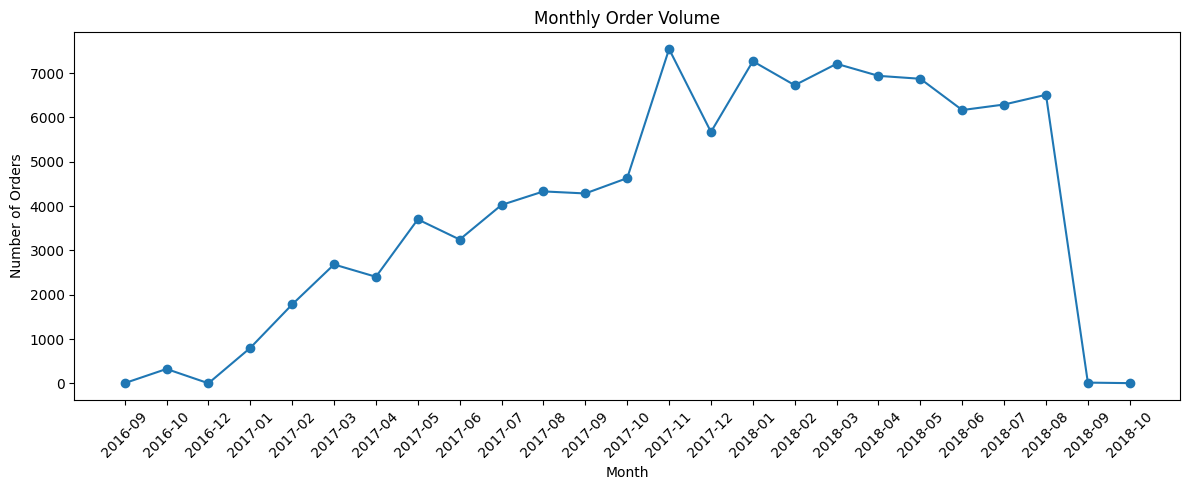

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['purchase_month'].astype(str),
    monthly_sales['orders'],
    marker='o'
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
order_master['purchase_month'] = (
    order_master['order_purchase_timestamp']
    .dt.to_period('M')
)

In [61]:
monthly_sales = (
    order_master
    .groupby('purchase_month')
    .agg(
        orders=('order_id', 'nunique'),
        payment_value=('total_payment', 'sum'),
        merchandise_value=('merchandise_value', 'sum')
    )
    .reset_index()
)

In [63]:
monthly_sales['aov'] = (
    monthly_sales['payment_value'] /
    monthly_sales['orders']
)

In [65]:
monthly_sales.head()

,purchase_month,orders,payment_value,merchandise_value,aov
0,2016-09,4,252.24,267.36,63.060000
1,2016-10,324,59090.48,49507.66,182.378025
2,2016-12,1,19.62,10.90,19.620000
3,2017-01,800,138488.04,120312.87,173.110050
4,2017-02,1780,291908.01,247303.02,163.993264


In [66]:
#order state analysis

In [68]:
status_summary = (
    order_master
    .groupby('order_status')
    .agg(
        orders=('order_id', 'nunique'),
        payment_value=('total_payment', 'sum')
    )
    .reset_index()
)

status_summary

,order_status,orders,payment_value
0,approved,2,241.08
1,canceled,625,143255.60
2,created,5,688.10
3,delivered,96478,15422461.77
4,invoiced,314,69137.99
5,processing,301,69394.11
6,shipped,1107,177213.96
7,unavailable,609,126479.51


In [70]:
status_summary['order_percentage'] = (
    status_summary['orders'] /
    status_summary['orders'].sum()
) * 100

In [72]:
status_summary

,order_status,orders,payment_value,order_percentage
0,approved,2,241.08,0.002011
1,canceled,625,143255.60,0.628513
2,created,5,688.10,0.005028
3,delivered,96478,15422461.77,97.020344
4,invoiced,314,69137.99,0.315765
5,processing,301,69394.11,0.302692
6,shipped,1107,177213.96,1.113223
7,unavailable,609,126479.51,0.612423


In [74]:
delivered_orders = order_master[
    order_master['order_status'] == 'delivered'
].copy()

In [76]:
delivered_orders.shape

(96478, 19)

In [78]:
delivered_orders['order_id'].nunique()

96478

In [80]:
#revenue from delivered orders
delivered_revenue = delivered_orders['total_payment'].sum()

delivered_aov = delivered_orders['total_payment'].mean()

print("Delivered Orders:", len(delivered_orders))
print("Delivered Payment Value:", delivered_revenue)
print("Delivered AOV:", delivered_aov)

Delivered Orders: 96478
Delivered Payment Value: 15422461.769999998
Delivered AOV: 159.85635716284708


In [82]:
#cancelled ordersrate
cancelled_orders = order_master[
    order_master['order_status'] == 'canceled'
]

cancellation_rate = (
    len(cancelled_orders) /
    len(order_master)
) * 100

print("Cancelled Orders:", len(cancelled_orders))
print("Cancellation Rate:", cancellation_rate, "%")

Cancelled Orders: 625
Cancellation Rate: 0.6285133898492574 %


In [84]:
#customer analysis
customer_orders = order_master.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

In [86]:
customer_orders[['customer_id', 'customer_unique_id']].head()

,customer_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff
1,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231
2,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8
3,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977
4,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6


In [89]:
#orders per customer
customer_order_counts = (
    customer_orders
    .groupby('customer_unique_id')
    .agg(
        order_count=('order_id', 'nunique'),
        total_spent=('total_payment', 'sum')
    )
    .reset_index()
)


In [91]:
customer_order_counts.head()

,customer_unique_id,order_count,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


In [93]:
#one time and multiple order customer
customer_order_counts['customer_type'] = customer_order_counts[
    'order_count'
].apply(
    lambda x: 'Repeat Customer' if x > 1 else 'One-time Customer'
)

In [95]:
customer_type_summary = (
    customer_order_counts['customer_type']
    .value_counts()
    .reset_index()
)

customer_type_summary.columns = [
    'customer_type',
    'customers'
]

customer_type_summary

,customer_type,customers
0,One-time Customer,93099
1,Repeat Customer,2997


In [97]:
total_customers = len(customer_order_counts)

repeat_customers = (
    customer_order_counts['order_count'] > 1
).sum()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print("Total Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", repeat_customer_rate, "%")

Total Customers: 96096
Repeat Customers: 2997
Repeat Customer Rate: 3.1187562437562435 %


In [99]:
customer_order_counts['order_count'].value_counts().sort_index()

1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: order_count, dtype: int64

In [101]:
#RFM
analysis_date = (
    customer_orders['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

analysis_date

Timestamp('2018-10-18 17:30:18')

In [103]:
rfm = (
    customer_orders
    .groupby('customer_unique_id')
    .agg(
        recency=('order_purchase_timestamp',
                 lambda x: (analysis_date - x.max()).days),
        
        frequency=('order_id', 'nunique'),
        
        monetary=('total_payment', 'sum')
    )
    .reset_index()
)

In [105]:
lambda x: (analysis_date - x.max()).days

<function __main__.<lambda>(x)>

In [107]:
frequency=('order_id', 'nunique')

In [109]:
monetary=('total_payment', 'sum')

In [111]:
rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [113]:
rfm.describe()

,recency,frequency,monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,166.592492
std,153.414676,0.214384,231.428332
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.120000
50%,269.000000,1.000000,108.000000
75%,398.000000,1.000000,183.530000
max,773.000000,17.000000,13664.080000


In [115]:
analysis_date = (
    customer_orders['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

In [116]:
rfm = (
    customer_orders
    .groupby('customer_unique_id')
    .agg(
        recency=('order_purchase_timestamp',
                 lambda x: (analysis_date - x.max()).days),
        frequency=('order_id', 'nunique'),
        monetary=('total_payment', 'sum')
    )
    .reset_index()
)

In [118]:
rfm.head()


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [120]:
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [122]:
rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [124]:
rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [126]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [128]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [130]:
rfm.head(10)

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214
5,0004bd2a26a76fe21f786e4fbd80607f,195,1,166.98,4,1,4,414
6,00050ab1314c0e55a6ca13cf7181fecf,181,1,35.38,4,1,1,411
7,00053a61a98854899e70ed204dd4bafe,232,1,419.18,3,1,5,315
8,0005e1862207bf6ccc02e4228effd9a0,592,1,150.12,1,1,4,114
9,0005ef4cd20d2893f0d9fbd94d3c0d97,220,1,129.76,4,1,3,413


In [132]:
rfm['RFM_score'].value_counts().head(20)

555    1057
455     984
255     934
355     911
222     886
242     874
155     868
531     864
424     856
131     855
454     845
331     835
544     830
212     829
142     828
132     826
344     825
112     823
121     821
122     819
Name: RFM_score, dtype: int64

In [133]:
#RFM SEGMENTATION

In [135]:
def rfm_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'High Value'
    
    elif row['R_score'] >= 4 and row['F_score'] >= 3:
        return 'Loyal / Active'
    
    elif row['R_score'] >= 4 and row['M_score'] >= 3:
        return 'Potential Loyalist'
    
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    
    elif row['R_score'] <= 2 and row['M_score'] >= 3:
        return 'High Value At Risk'
    
    else:
        return 'Other'

In [137]:
rfm['segment'] = rfm.apply(rfm_segment, axis=1)

In [139]:
segment_summary = (
    rfm['segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    'segment',
    'customers'
]

segment_summary

,segment,customers
0,Other,31606
1,At Risk,22967
2,Loyal / Active,16462
3,Potential Loyalist,9386
4,High Value At Risk,8963
5,High Value,6712


In [141]:
segment_summary['percentage'] = (
    segment_summary['customers'] /
    segment_summary['customers'].sum()
) * 100

In [143]:
segment_summary

,segment,customers,percentage
0,Other,31606,32.890027
1,At Risk,22967,23.900058
2,Loyal / Active,16462,17.130786
3,Potential Loyalist,9386,9.767316
4,High Value At Risk,8963,9.327131
5,High Value,6712,6.984682


In [145]:
segment_value = (
    rfm
    .groupby('segment')
    .agg(
        customers=('customer_unique_id', 'count'),
        total_spent=('monetary', 'sum'),
        average_spent=('monetary', 'mean'),
        average_frequency=('frequency', 'mean'),
        average_recency=('recency', 'mean')
    )
    .reset_index()
)

In [147]:
segment_value

,segment,customers,total_spent,average_spent,average_frequency,average_recency
0,At Risk,22967,3877581.43,168.832735,1.049593,445.737711
1,High Value,6712,2131028.81,317.495353,1.190107,141.030691
2,High Value At Risk,8963,2176212.56,242.799572,1.000000,446.079772
3,Loyal / Active,16462,1924126.56,116.882916,1.015004,140.370247
4,Other,31606,3689777.01,116.742929,1.021610,282.448333
5,Potential Loyalist,9386,2210145.75,235.472592,1.000000,141.321010


In [148]:
#COHORT ANALYSIS

In [178]:
# Create a fresh cohort dataset
cohort_data = customer_orders[
    [
        'customer_unique_id',
        'order_id',
        'order_purchase_timestamp'
    ]
].copy()

# Convert purchase date to month
cohort_data['purchase_month'] = (
    cohort_data['order_purchase_timestamp'].dt.to_period('M')
)

# Find each customer's first purchase month
first_purchase = (
    cohort_data
    .groupby('customer_unique_id')['purchase_month']
    .min()
    .reset_index()
    .rename(columns={'purchase_month': 'cohort_month'})
)

# Add cohort month to every customer's purchase
cohort_data = cohort_data.merge(
    first_purchase,
    on='customer_unique_id',
    how='left'
)

# Calculate months since first purchase
cohort_data['cohort_period'] = (
    (cohort_data['purchase_month'].dt.year -
     cohort_data['cohort_month'].dt.year) * 12
    +
    (cohort_data['purchase_month'].dt.month -
     cohort_data['cohort_month'].dt.month)
)

In [181]:
cohort_data.columns.tolist()

['customer_unique_id',
 'order_id',
 'order_purchase_timestamp',
 'purchase_month',
 'cohort_month',
 'cohort_period']

In [183]:
cohort_data.head()


,customer_unique_id,order_id,order_purchase_timestamp,purchase_month,cohort_month,cohort_period
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,2017-09,1
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02,2018-02,0


In [184]:
#COHORT RETENTION

In [186]:
cohort_counts = (
    cohort_data
    .groupby(['cohort_month', 'cohort_period'])
    ['customer_unique_id']
    .nunique()
    .reset_index()
)

In [188]:
cohort_table = cohort_counts.pivot(
    index='cohort_month',
    columns='cohort_period',
    values='customer_unique_id'
)

In [190]:
cohort_table.head()

cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


In [192]:
cohort_retention = (
    cohort_table
    .divide(cohort_table[0], axis=0)
) * 100

In [194]:
cohort_retention.head()

cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.311526,NaN,NaN,0.311526,NaN,0.311526,NaN,0.311526,NaN,0.311526,NaN,0.311526,0.623053,0.623053
2016-12,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.392670,0.261780,0.130890,0.392670,0.130890,0.523560,0.130890,0.130890,NaN,0.392670,0.130890,0.785340,0.392670,0.130890,0.130890,0.261780,0.392670,0.130890,NaN
2017-02,100.0,0.228311,0.285388,0.114155,0.399543,0.114155,0.228311,0.171233,0.171233,0.228311,0.114155,0.285388,0.171233,0.171233,0.114155,0.057078,0.057078,0.228311,NaN,NaN


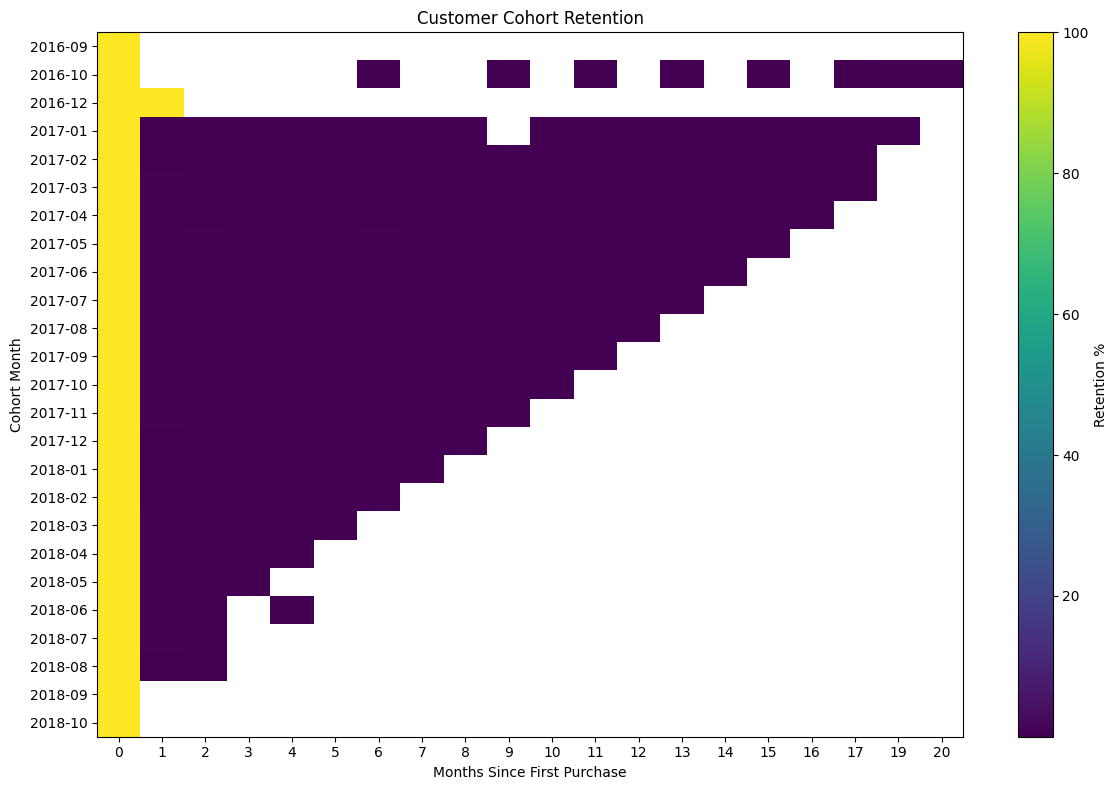

In [196]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(
    cohort_retention,
    aspect='auto'
)

plt.colorbar(label='Retention %')

plt.title('Customer Cohort Retention')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.xticks(
    range(len(cohort_retention.columns)),
    cohort_retention.columns
)

plt.yticks(
    range(len(cohort_retention.index)),
    cohort_retention.index.astype(str)
)

plt.tight_layout()
plt.show()

In [198]:
cohort_counts = (
    cohort_data
    .groupby(['cohort_month', 'cohort_period'])
    ['customer_unique_id']
    .nunique()
    .reset_index()
)

In [200]:
cohort_table = cohort_counts.pivot(
    index='cohort_month',
    columns='cohort_period',
    values='customer_unique_id'
)

In [202]:
cohort_retention = (
    cohort_table
    .divide(cohort_table[0], axis=0)
) * 100

In [204]:
cohort_retention.head()

cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.311526,NaN,NaN,0.311526,NaN,0.311526,NaN,0.311526,NaN,0.311526,NaN,0.311526,0.623053,0.623053
2016-12,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.392670,0.261780,0.130890,0.392670,0.130890,0.523560,0.130890,0.130890,NaN,0.392670,0.130890,0.785340,0.392670,0.130890,0.130890,0.261780,0.392670,0.130890,NaN
2017-02,100.0,0.228311,0.285388,0.114155,0.399543,0.114155,0.228311,0.171233,0.171233,0.228311,0.114155,0.285388,0.171233,0.171233,0.114155,0.057078,0.057078,0.228311,NaN,NaN


In [205]:
#PRODUCT AND CATEGORY ANALYSIS

In [207]:
delivered_order_ids = delivered_orders['order_id']

In [209]:
delivered_items = order_items[
    order_items['order_id'].isin(delivered_order_ids)
].copy()

In [211]:
delivered_items.shape

(110197, 7)

In [213]:
product_sales = delivered_items.merge(
    products,
    on='product_id',
    how='left'
)

In [215]:
product_sales.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [230]:
#category names
# Rebuild product_sales cleanly

product_sales = delivered_items.merge(
    products[
        [
            'product_id',
            'product_category_name'
        ]
    ],
    on='product_id',
    how='left'
)

product_sales = product_sales.merge(
    category_translation[
        [
            'product_category_name',
            'product_category_name_english'
        ]
    ],
    on='product_category_name',
    how='left'
)

In [232]:
product_sales.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_category_name_english']

In [234]:
product_sales[
    [
        'product_id',
        'product_category_name',
        'product_category_name_english',
        'price'
    ]
].head()

,product_id,product_category_name,product_category_name_english,price
0,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,cool_stuff,58.90
1,e5f2d52b802189ee658865ca93d83a8f,pet_shop,pet_shop,239.90
2,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,furniture_decor,199.00
3,7634da152a4610f1595efa32f14722fc,perfumaria,perfumery,12.99
4,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,garden_tools,199.90


In [236]:
#category performances
category_sales = (
    product_sales
    .groupby('product_category_name_english')
    .agg(
        items_sold=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        average_price=('price', 'mean')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

In [238]:
category_sales.head(10)

,product_category_name_english,items_sold,revenue,average_price
43,health_beauty,9465,1233131.72,130.283330
70,watches_gifts,5859,1166176.98,199.040276
7,bed_bath_table,10953,1023434.76,93.438762
65,sports_leisure,8431,954852.55,113.254958
15,computers_accessories,7644,888724.61,116.264339
39,furniture_decor,8160,711927.69,87.246040
49,housewares,6795,615628.69,90.600249
20,cool_stuff,3718,610204.10,164.121598
5,auto,4140,578966.65,139.847017
69,toys,4030,471286.48,116.944536


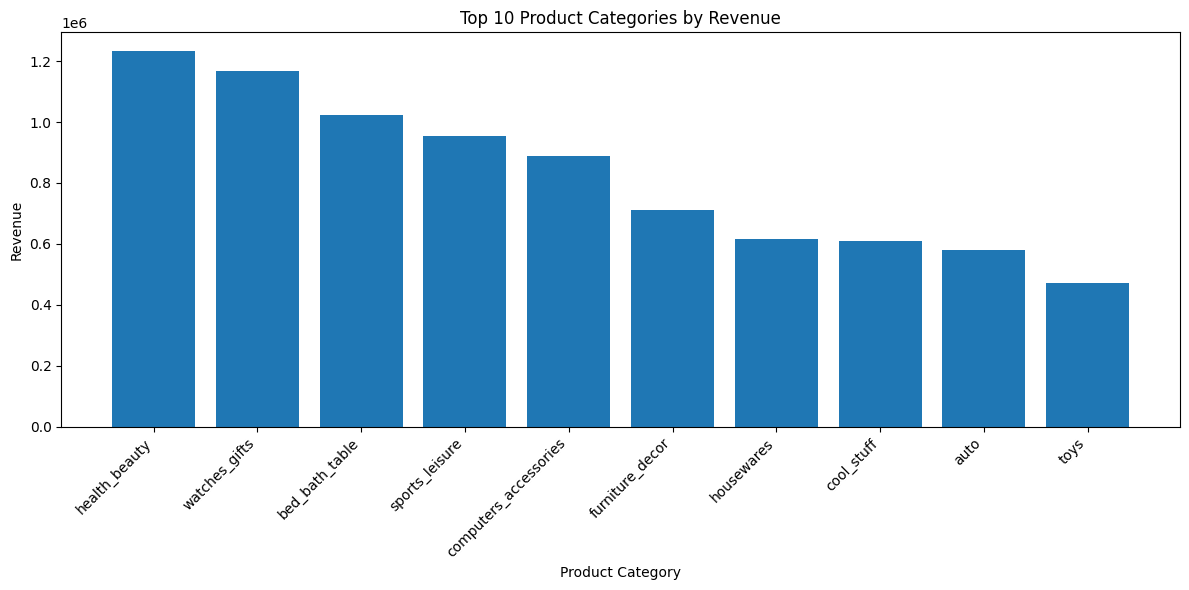

In [240]:
top_categories = category_sales.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_categories['product_category_name_english'],
    top_categories['revenue']
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [242]:
top_categories[['product_category_name_english',
                'items_sold',
                'revenue',
                'average_price']].head(10)

,product_category_name_english,items_sold,revenue,average_price
43,health_beauty,9465,1233131.72,130.283330
70,watches_gifts,5859,1166176.98,199.040276
7,bed_bath_table,10953,1023434.76,93.438762
65,sports_leisure,8431,954852.55,113.254958
15,computers_accessories,7644,888724.61,116.264339
39,furniture_decor,8160,711927.69,87.246040
49,housewares,6795,615628.69,90.600249
20,cool_stuff,3718,610204.10,164.121598
5,auto,4140,578966.65,139.847017
69,toys,4030,471286.48,116.944536


In [244]:
product_performance = (
    product_sales
    .groupby('product_id')
    .agg(
        items_sold=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        average_price=('price', 'mean')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

In [246]:
product_performance.head(10)

,product_id,items_sold,revenue,average_price
23546,bb50f2e236e5eea0100680137654686c,194,63560.00,327.628866
13749,6cdd53843498f92890544667809f1595,153,53652.30,350.668627
26997,d6160fb7873f184099d9bc95e30376af,33,45949.35,1392.404545
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,45620.56,137.411325
19290,99a4788cb24856965c36a24e339b6058,477,42049.66,88.154423
7881,3dd2a17168ec895c781a9191c1e95ad7,272,40782.80,149.936765
4892,25c38557cf793876c5abdd5931f922db,38,38907.32,1023.876842
12074,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90,598.950794
10616,53b36df67ebb7c41585e8d54d6772e08,321,37454.63,116.681090
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,37104.30,71.354423


In [248]:
category_sales.head(10)

,product_category_name_english,items_sold,revenue,average_price
43,health_beauty,9465,1233131.72,130.283330
70,watches_gifts,5859,1166176.98,199.040276
7,bed_bath_table,10953,1023434.76,93.438762
65,sports_leisure,8431,954852.55,113.254958
15,computers_accessories,7644,888724.61,116.264339
39,furniture_decor,8160,711927.69,87.246040
49,housewares,6795,615628.69,90.600249
20,cool_stuff,3718,610204.10,164.121598
5,auto,4140,578966.65,139.847017
69,toys,4030,471286.48,116.944536


In [249]:
#delivery performance
delivery_summary = order_master[
    order_master['order_status'] == 'delivered'
][
    ['delivery_days', 'delivery_delay_days']
].describe()

delivery_summary

,delivery_days,delivery_delay_days
count,96470.000000,96470.000000
mean,12.093604,-11.875889
std,9.551380,10.182105
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [250]:
delivered = order_master[
    order_master['order_status'] == 'delivered'
]

late_orders = delivered['is_late'].sum()

late_delivery_rate = (
    late_orders / len(delivered)
) * 100

print("Delivered Orders:", len(delivered))
print("Late Orders:", late_orders)
print("Late Delivery Rate:", late_delivery_rate, "%")

Delivered Orders: 96478
Late Orders: 6534
Late Delivery Rate: 6.77252845208234 %


In [251]:
delivery_status = (
    delivered['is_late']
    .value_counts()
    .rename(index={
        False: 'On Time',
        True: 'Late'
    })
    .reset_index()
)

delivery_status.columns = [
    'delivery_status',
    'orders'
]

delivery_status

,delivery_status,orders
0,On Time,89944
1,Late,6534


In [252]:
#delivery vs review
delivery_reviews = (
    delivered
    .groupby('is_late')
    .agg(
        orders=('order_id', 'nunique'),
        average_review_score=('review_score', 'mean')
    )
    .reset_index()
)

delivery_reviews['delivery_status'] = delivery_reviews['is_late'].map({
    False: 'On Time',
    True: 'Late'
})

delivery_reviews

,is_late,orders,average_review_score,delivery_status
0,False,89944,4.290608,On Time
1,True,6534,2.271823,Late


In [254]:
on_time_score = delivery_reviews.loc[
    delivery_reviews['is_late'] == False,
    'average_review_score'
].iloc[0]

late_score = delivery_reviews.loc[
    delivery_reviews['is_late'] == True,
    'average_review_score'
].iloc[0]

score_difference = on_time_score - late_score

print("On-time average review:", on_time_score)
print("Late average review:", late_score)
print("Difference:", score_difference)

On-time average review: 4.290607893334526
Late average review: 2.2718225983388183
Difference: 2.0187852949957077


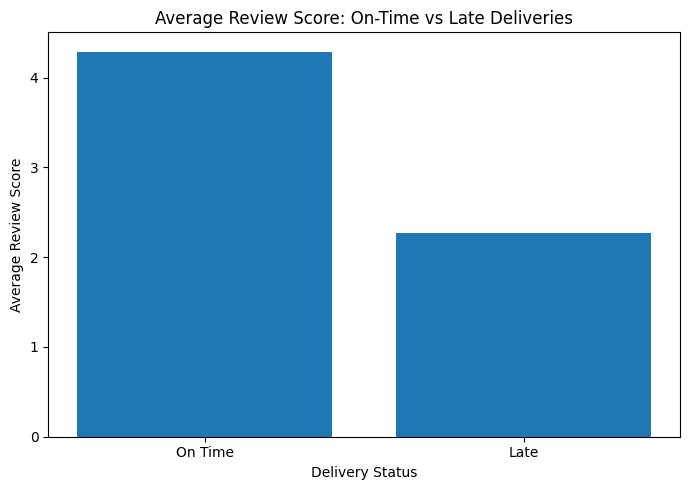

In [255]:
plt.figure(figsize=(7, 5))

plt.bar(
    delivery_reviews['delivery_status'],
    delivery_reviews['average_review_score']
)

plt.title('Average Review Score: On-Time vs Late Deliveries')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')

plt.tight_layout()
plt.show()

In [257]:
#customer satisfaction
review_summary = order_master['review_score'].describe()

review_summary

count    98673.000000
mean         4.086793
std          1.346274
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [259]:
average_review = order_master['review_score'].mean()

print("Average Review Score:", average_review)

Average Review Score: 4.0867934152875325


In [261]:
review_distribution = (
    order_master['review_score']
    .value_counts()
    .sort_index()
    .reset_index()
)

review_distribution.columns = [
    'review_score',
    'orders'
]

review_distribution

,review_score,orders
0,1.000000,11316
1,1.500000,8
2,2.000000,3125
3,2.500000,34
4,3.000000,8136
5,3.333333,1
6,3.500000,25
7,4.000000,19018
8,4.333333,1
9,4.500000,54


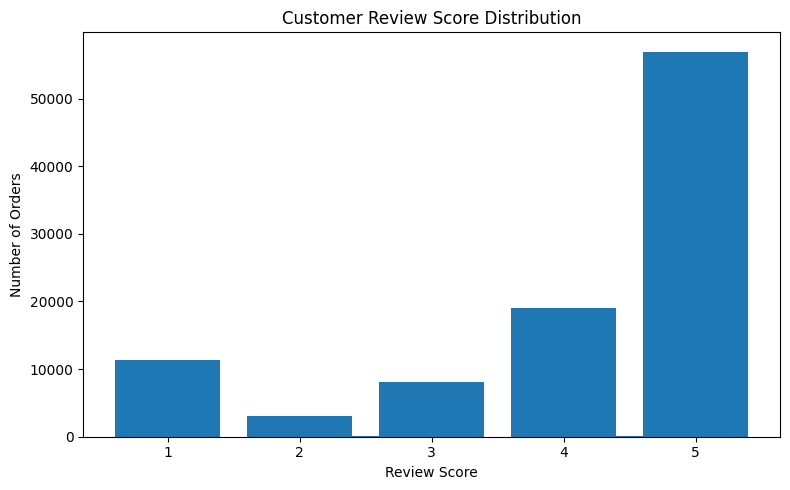

In [263]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_distribution['review_score'],
    review_distribution['orders']
)

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')

plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

In [265]:
low_rated_orders = order_master[
    order_master['review_score'] <= 2
].copy()

In [267]:
low_rating_rate = (
    len(low_rated_orders) /
    order_master['review_score'].notna().sum()
) * 100

print("Low-rated orders:", len(low_rated_orders))
print("Low-rating rate:", low_rating_rate, "%")

Low-rated orders: 14449
Low-rating rate: 14.643316814123416 %


In [269]:
order_master['review_score'].notna().sum()

98673

In [271]:
review_delivery = (
    delivered
    .groupby('review_score')
    .agg(
        orders=('order_id', 'nunique'),
        average_delay_days=('delivery_delay_days', 'mean'),
        average_delivery_days=('delivery_days', 'mean')
    )
    .reset_index()
)

review_delivery

,review_score,orders,average_delay_days,average_delivery_days
0,1.000000,9313,-4.013531,20.878007
1,1.500000,8,-6.000000,17.000000
2,2.000000,2916,-8.635460,16.197874
3,2.500000,30,-7.566667,18.266667
4,3.000000,7915,-10.782565,13.777258
5,3.333333,1,-14.000000,22.000000
6,3.500000,23,-13.956522,12.913043
7,4.000000,18868,-12.379584,11.842432
8,4.333333,1,-11.000000,3.000000
9,4.500000,53,-13.037736,12.301887


In [273]:
#buisness opportunity kpi
kpi_summary = {
    'total_orders': total_orders,
    'total_customers': total_customers,
    'total_payment_value': total_payment,
    'average_order_value': average_order_value,
    'repeat_customer_rate': repeat_customer_rate,
    'cancellation_rate': cancellation_rate,
    'late_delivery_rate': late_delivery_rate,
    'average_review_score': average_review
}

kpi_summary

{'total_orders': 99441,
 'total_customers': 96096,
 'total_payment_value': 16008872.120000001,
 'average_order_value': 160.9902666934835,
 'repeat_customer_rate': 3.1187562437562435,
 'cancellation_rate': 0.6285133898492574,
 'late_delivery_rate': 6.77252845208234,
 'average_review_score': 4.0867934152875325}

In [275]:
segment_value.sort_values(
    'total_spent',
    ascending=False
)

,segment,customers,total_spent,average_spent,average_frequency,average_recency
0,At Risk,22967,3877581.43,168.832735,1.049593,445.737711
4,Other,31606,3689777.01,116.742929,1.021610,282.448333
5,Potential Loyalist,9386,2210145.75,235.472592,1.000000,141.321010
2,High Value At Risk,8963,2176212.56,242.799572,1.000000,446.079772
1,High Value,6712,2131028.81,317.495353,1.190107,141.030691
3,Loyal / Active,16462,1924126.56,116.882916,1.015004,140.370247


In [277]:
segment_value.sort_values(
    'customers',
    ascending=False
)

,segment,customers,total_spent,average_spent,average_frequency,average_recency
4,Other,31606,3689777.01,116.742929,1.021610,282.448333
0,At Risk,22967,3877581.43,168.832735,1.049593,445.737711
3,Loyal / Active,16462,1924126.56,116.882916,1.015004,140.370247
5,Potential Loyalist,9386,2210145.75,235.472592,1.000000,141.321010
2,High Value At Risk,8963,2176212.56,242.799572,1.000000,446.079772
1,High Value,6712,2131028.81,317.495353,1.190107,141.030691


In [279]:
category_sales['revenue_percentage'] = (
    category_sales['revenue'] /
    category_sales['revenue'].sum()
) * 100

In [281]:
category_sales.head(10)

,product_category_name_english,items_sold,revenue,average_price,revenue_percentage
43,health_beauty,9465,1233131.72,130.283330,9.452522
70,watches_gifts,5859,1166176.98,199.040276,8.939283
7,bed_bath_table,10953,1023434.76,93.438762,7.845099
65,sports_leisure,8431,954852.55,113.254958,7.319384
15,computers_accessories,7644,888724.61,116.264339,6.812483
39,furniture_decor,8160,711927.69,87.246040,5.457253
49,housewares,6795,615628.69,90.600249,4.719077
20,cool_stuff,3718,610204.10,164.121598,4.677495
5,auto,4140,578966.65,139.847017,4.438046
69,toys,4030,471286.48,116.944536,3.612628


In [283]:
top10_category_share = (
    category_sales
    .head(10)['revenue']
    .sum()
    /
    category_sales['revenue'].sum()
) * 100

print(
    "Top 10 categories revenue share:",
    top10_category_share,
    "%"
)

Top 10 categories revenue share: 63.273271845149694 %


In [285]:
late_review_difference = (
    delivery_reviews.loc[
        delivery_reviews['delivery_status'] == 'On Time',
        'average_review_score'
    ].iloc[0]
    -
    delivery_reviews.loc[
        delivery_reviews['delivery_status'] == 'Late',
        'average_review_score'
    ].iloc[0]
)

print(
    "Review score difference:",
    late_review_difference
)

Review score difference: 2.0187852949957077


In [286]:
kpi_summary

{'total_orders': 99441,
 'total_customers': 96096,
 'total_payment_value': 16008872.120000001,
 'average_order_value': 160.9902666934835,
 'repeat_customer_rate': 3.1187562437562435,
 'cancellation_rate': 0.6285133898492574,
 'late_delivery_rate': 6.77252845208234,
 'average_review_score': 4.0867934152875325}

In [287]:
segment_value.sort_values('total_spent', ascending=False)

,segment,customers,total_spent,average_spent,average_frequency,average_recency
0,At Risk,22967,3877581.43,168.832735,1.049593,445.737711
4,Other,31606,3689777.01,116.742929,1.021610,282.448333
5,Potential Loyalist,9386,2210145.75,235.472592,1.000000,141.321010
2,High Value At Risk,8963,2176212.56,242.799572,1.000000,446.079772
1,High Value,6712,2131028.81,317.495353,1.190107,141.030691
3,Loyal / Active,16462,1924126.56,116.882916,1.015004,140.370247


In [288]:
category_sales.head(10)

,product_category_name_english,items_sold,revenue,average_price,revenue_percentage
43,health_beauty,9465,1233131.72,130.283330,9.452522
70,watches_gifts,5859,1166176.98,199.040276,8.939283
7,bed_bath_table,10953,1023434.76,93.438762,7.845099
65,sports_leisure,8431,954852.55,113.254958,7.319384
15,computers_accessories,7644,888724.61,116.264339,6.812483
39,furniture_decor,8160,711927.69,87.246040,5.457253
49,housewares,6795,615628.69,90.600249,4.719077
20,cool_stuff,3718,610204.10,164.121598,4.677495
5,auto,4140,578966.65,139.847017,4.438046
69,toys,4030,471286.48,116.944536,3.612628


In [289]:
top10_category_share

63.273271845149694

In [290]:
kpi_summary = {
    'total_orders': total_orders,
    'total_customers': total_customers,
    'total_payment_value': total_payment,
    'average_order_value': average_order_value,
    'repeat_customer_rate': repeat_customer_rate,
    'cancellation_rate': cancellation_rate,
    'late_delivery_rate': late_delivery_rate,
    'average_review_score': average_review
}

kpi_summary

{'total_orders': 99441,
 'total_customers': 96096,
 'total_payment_value': 16008872.120000001,
 'average_order_value': 160.9902666934835,
 'repeat_customer_rate': 3.1187562437562435,
 'cancellation_rate': 0.6285133898492574,
 'late_delivery_rate': 6.77252845208234,
 'average_review_score': 4.0867934152875325}

In [291]:
segment_value.sort_values(
    'total_spent',
    ascending=False
)

,segment,customers,total_spent,average_spent,average_frequency,average_recency
0,At Risk,22967,3877581.43,168.832735,1.049593,445.737711
4,Other,31606,3689777.01,116.742929,1.021610,282.448333
5,Potential Loyalist,9386,2210145.75,235.472592,1.000000,141.321010
2,High Value At Risk,8963,2176212.56,242.799572,1.000000,446.079772
1,High Value,6712,2131028.81,317.495353,1.190107,141.030691
3,Loyal / Active,16462,1924126.56,116.882916,1.015004,140.370247


In [292]:
segment_value.sort_values(
    'customers',
    ascending=False
)

,segment,customers,total_spent,average_spent,average_frequency,average_recency
4,Other,31606,3689777.01,116.742929,1.021610,282.448333
0,At Risk,22967,3877581.43,168.832735,1.049593,445.737711
3,Loyal / Active,16462,1924126.56,116.882916,1.015004,140.370247
5,Potential Loyalist,9386,2210145.75,235.472592,1.000000,141.321010
2,High Value At Risk,8963,2176212.56,242.799572,1.000000,446.079772
1,High Value,6712,2131028.81,317.495353,1.190107,141.030691


In [293]:
category_sales['revenue_percentage'] = (
    category_sales['revenue']
    / category_sales['revenue'].sum()
) * 100

In [294]:
category_sales.head(10)

,product_category_name_english,items_sold,revenue,average_price,revenue_percentage
43,health_beauty,9465,1233131.72,130.283330,9.452522
70,watches_gifts,5859,1166176.98,199.040276,8.939283
7,bed_bath_table,10953,1023434.76,93.438762,7.845099
65,sports_leisure,8431,954852.55,113.254958,7.319384
15,computers_accessories,7644,888724.61,116.264339,6.812483
39,furniture_decor,8160,711927.69,87.246040,5.457253
49,housewares,6795,615628.69,90.600249,4.719077
20,cool_stuff,3718,610204.10,164.121598,4.677495
5,auto,4140,578966.65,139.847017,4.438046
69,toys,4030,471286.48,116.944536,3.612628


In [295]:
top10_category_share = (
    category_sales.head(10)['revenue'].sum()
    / category_sales['revenue'].sum()
) * 100

print(
    "Top 10 categories revenue share:",
    top10_category_share,
    "%"
)

Top 10 categories revenue share: 63.273271845149694 %


In [296]:
delivery_reviews

,is_late,orders,average_review_score,delivery_status
0,False,89944,4.290608,On Time
1,True,6534,2.271823,Late


In [297]:
late_review_difference = (
    delivery_reviews.loc[
        delivery_reviews['delivery_status'] == 'On Time',
        'average_review_score'
    ].iloc[0]
    -
    delivery_reviews.loc[
        delivery_reviews['delivery_status'] == 'Late',
        'average_review_score'
    ].iloc[0]
)

print(
    "Review score difference:",
    late_review_difference
)

Review score difference: 2.0187852949957077


In [298]:
segment_value.sort_values(
    'total_spent',
    ascending=False
)

,segment,customers,total_spent,average_spent,average_frequency,average_recency
0,At Risk,22967,3877581.43,168.832735,1.049593,445.737711
4,Other,31606,3689777.01,116.742929,1.021610,282.448333
5,Potential Loyalist,9386,2210145.75,235.472592,1.000000,141.321010
2,High Value At Risk,8963,2176212.56,242.799572,1.000000,446.079772
1,High Value,6712,2131028.81,317.495353,1.190107,141.030691
3,Loyal / Active,16462,1924126.56,116.882916,1.015004,140.370247


In [299]:
segment_value.sort_values(
    'customers',
    ascending=False
)

,segment,customers,total_spent,average_spent,average_frequency,average_recency
4,Other,31606,3689777.01,116.742929,1.021610,282.448333
0,At Risk,22967,3877581.43,168.832735,1.049593,445.737711
3,Loyal / Active,16462,1924126.56,116.882916,1.015004,140.370247
5,Potential Loyalist,9386,2210145.75,235.472592,1.000000,141.321010
2,High Value At Risk,8963,2176212.56,242.799572,1.000000,446.079772
1,High Value,6712,2131028.81,317.495353,1.190107,141.030691


In [300]:
category_sales['revenue_percentage'] = (
    category_sales['revenue']
    / category_sales['revenue'].sum()
) * 100

In [302]:
category_sales.head(10)

,product_category_name_english,items_sold,revenue,average_price,revenue_percentage
43,health_beauty,9465,1233131.72,130.283330,9.452522
70,watches_gifts,5859,1166176.98,199.040276,8.939283
7,bed_bath_table,10953,1023434.76,93.438762,7.845099
65,sports_leisure,8431,954852.55,113.254958,7.319384
15,computers_accessories,7644,888724.61,116.264339,6.812483
39,furniture_decor,8160,711927.69,87.246040,5.457253
49,housewares,6795,615628.69,90.600249,4.719077
20,cool_stuff,3718,610204.10,164.121598,4.677495
5,auto,4140,578966.65,139.847017,4.438046
69,toys,4030,471286.48,116.944536,3.612628


In [303]:
print(delivery_reviews)

print(
    f"On-time vs late review score difference: "
    f"{late_review_difference:.2f}"
)


   is_late  orders  average_review_score delivery_status
0    False   89944              4.290608         On Time
1     True    6534              2.271823            Late
On-time vs late review score difference: 2.02


In [304]:
#review_delivery

In [305]:
delivery_review_corr = delivered[
    ['delivery_delay_days', 'review_score']
].dropna().corr().loc[
    'delivery_delay_days', 'review_score'
]

print(f"Correlation between delivery delay and review score: {delivery_review_corr:.3f}")

Correlation between delivery delay and review score: -0.267


In [306]:
frequency_spending_corr = rfm[
    ['frequency', 'monetary']
].corr().loc['frequency', 'monetary']

print(
    f"Correlation between purchase frequency and spending: "
    f"{frequency_spending_corr:.3f}"
)

Correlation between purchase frequency and spending: 0.126


In [307]:
frequency_distribution = (
    rfm['frequency']
    .value_counts()
    .sort_index()
)

frequency_distribution.head(10)

1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: frequency, dtype: int64

In [308]:
top_customers = (
    rfm
    .nlargest(20, 'monetary')
    [['customer_unique_id', 'frequency', 'monetary', 'recency', 'segment']]
)

top_customers

,customer_unique_id,frequency,monetary,recency,segment
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,384,High Value At Risk
26456,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,61,High Value
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,565,At Risk
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,95,Loyal / Active
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,612,At Risk
26205,459bef486812aa25204be022145caa62,1,6922.21,84,Potential Loyalist
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,511,At Risk
24121,4007669dec559734d6f53e029e360987,1,6081.54,328,High Value At Risk
35070,5d0a2980b292d049061542014e8960bf,1,4809.44,98,Potential Loyalist
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,547,At Risk


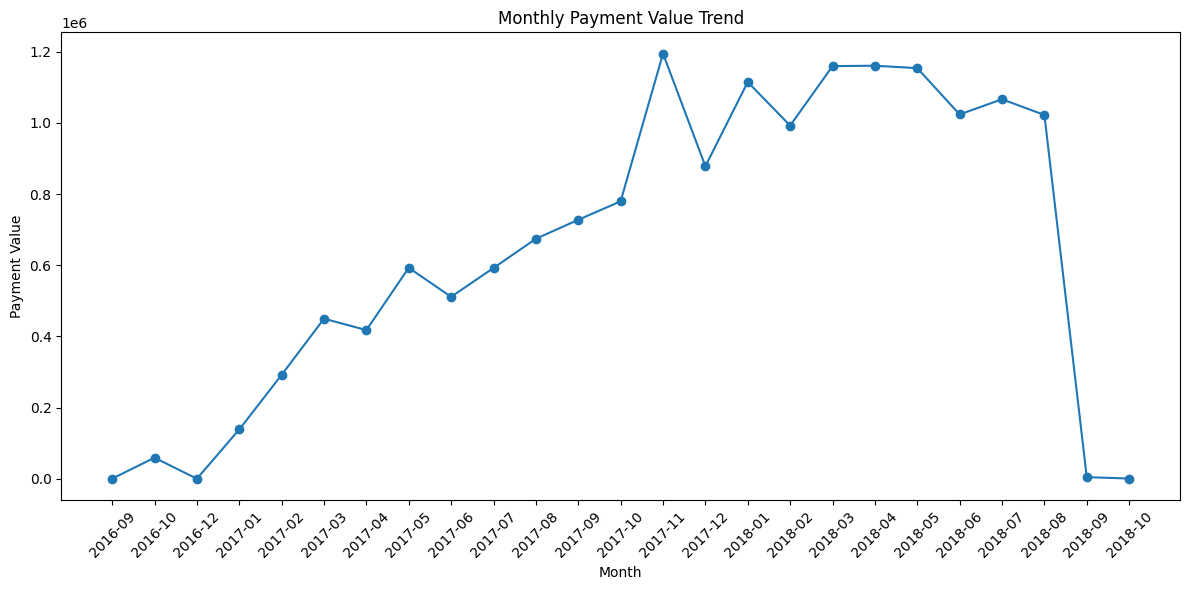

In [310]:
#final visualizations
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['purchase_month'].astype(str),
    monthly_sales['payment_value'],
    marker='o'
)

plt.title('Monthly Payment Value Trend')
plt.xlabel('Month')
plt.ylabel('Payment Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

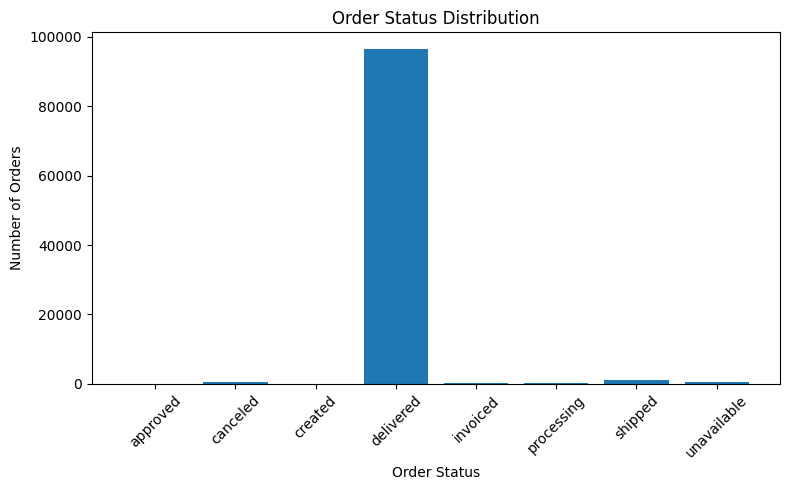

In [311]:
plt.figure(figsize=(8, 5))

plt.bar(
    status_summary['order_status'],
    status_summary['orders']
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

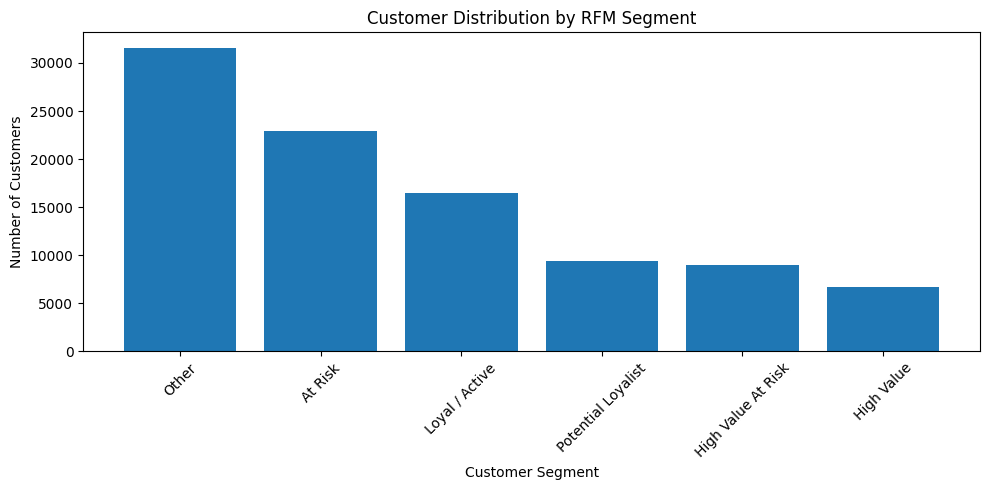

In [312]:
plt.figure(figsize=(10, 5))

plt.bar(
    segment_summary['segment'],
    segment_summary['customers']
)

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

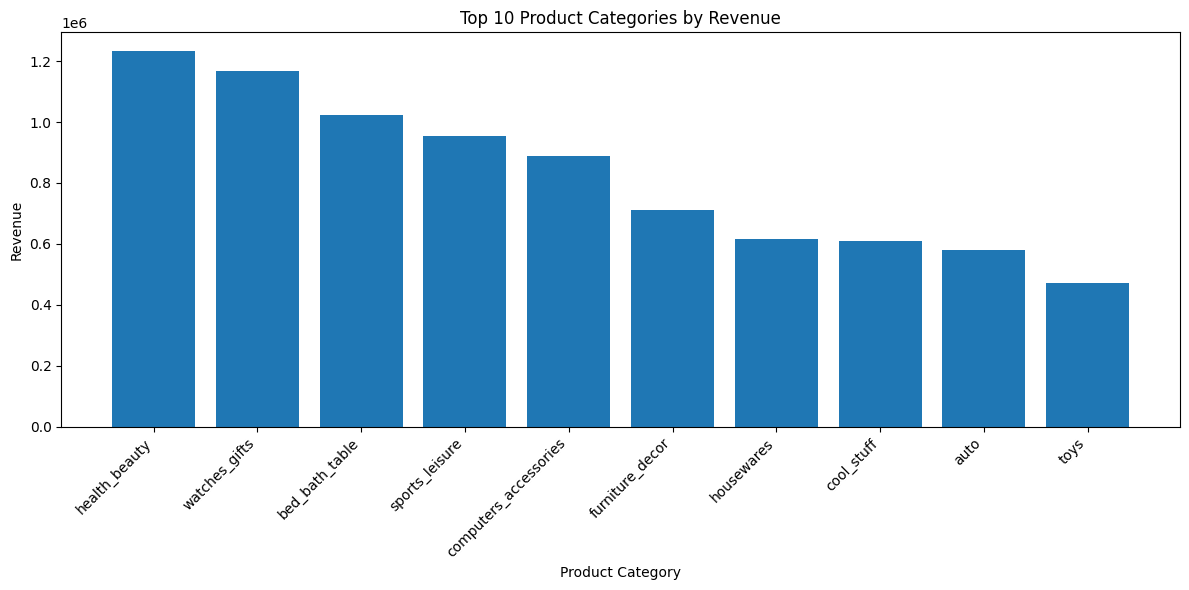

In [314]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_categories['product_category_name_english'],
    top_categories['revenue']
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

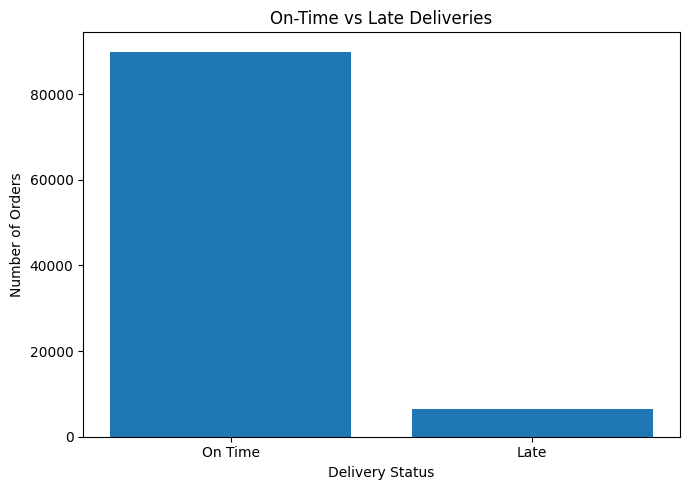

In [316]:
plt.figure(figsize=(7, 5))

plt.bar(
    delivery_status['delivery_status'],
    delivery_status['orders']
)

plt.title('On-Time vs Late Deliveries')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

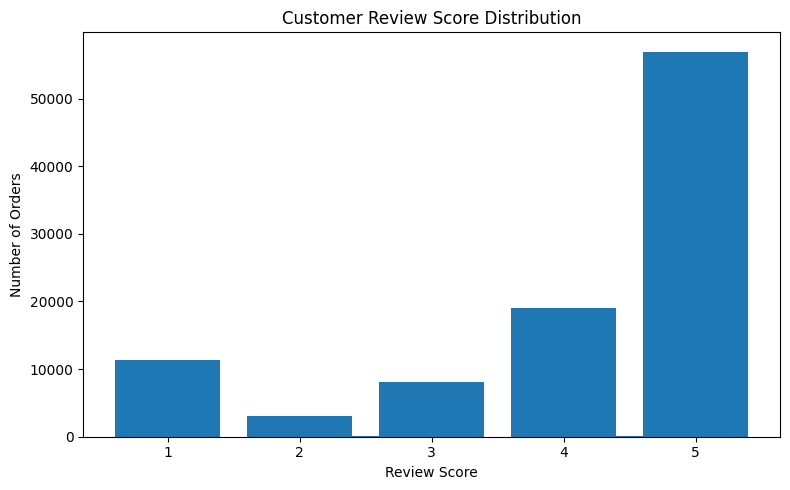

In [318]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_distribution['review_score'],
    review_distribution['orders']
)

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

In [320]:
#buisness insights
kpi_summary

{'total_orders': 99441,
 'total_customers': 96096,
 'total_payment_value': 16008872.120000001,
 'average_order_value': 160.9902666934835,
 'repeat_customer_rate': 3.1187562437562435,
 'cancellation_rate': 0.6285133898492574,
 'late_delivery_rate': 6.77252845208234,
 'average_review_score': 4.0867934152875325}

In [322]:
print("===== SALES =====")
print(f"Total orders: {total_orders:,}")
print(f"Total customers: {total_customers:,}")
print(f"Total payment value: {total_payment:,.2f}")
print(f"Average order value: {average_order_value:,.2f}")
print(f"Cancellation rate: {cancellation_rate:.2f}%")

print("\n===== CUSTOMERS =====")
print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")

print("\n===== DELIVERY =====")
print(f"Late delivery rate: {late_delivery_rate:.2f}%")
print(f"Average review score: {average_review:.2f}")

print("\n===== CATEGORIES =====")
print(f"Top 10 category revenue share: {top10_category_share:.2f}%")

print("\n===== DELIVERY → REVIEWS =====")
print(f"Review score difference (on-time vs late): {late_review_difference:.2f}")

print("\n===== RFM =====")
print(segment_value.sort_values(
    'total_spent',
    ascending=False
)[[
    'segment',
    'customers',
    'total_spent',
    'average_spent'
]].to_string(index=False))

===== SALES =====
Total orders: 99,441
Total customers: 96,096
Total payment value: 16,008,872.12
Average order value: 160.99
Cancellation rate: 0.63%

===== CUSTOMERS =====
Repeat customer rate: 3.12%

===== DELIVERY =====
Late delivery rate: 6.77%
Average review score: 4.09

===== CATEGORIES =====
Top 10 category revenue share: 63.27%

===== DELIVERY → REVIEWS =====
Review score difference (on-time vs late): 2.02

===== RFM =====
           segment  customers  total_spent  average_spent
           At Risk      22967   3877581.43     168.832735
             Other      31606   3689777.01     116.742929
Potential Loyalist       9386   2210145.75     235.472592
High Value At Risk       8963   2176212.56     242.799572
        High Value       6712   2131028.81     317.495353
    Loyal / Active      16462   1924126.56     116.882916
